In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls, minimize

df = pd.read_csv("data.csv", index_col=0)
df

,PSC,JUNTS,ERC,PP,VOX,COMUNS,CUP,ALIANÇA.CAT,Altres candidatures,Cs,Abstenció
1980,0.138185,0.171275,0.054873,0.014556,0.000000,0.115557,0.000000,0.000000,0.117144,0.000000,0.388410
1984,0.193811,0.301318,0.028411,0.049647,0.000000,0.035962,0.000000,0.000000,0.031802,0.000000,0.359048
1988,0.177197,0.272179,0.024616,0.031648,0.000000,0.046166,0.000000,0.000000,0.039541,0.000000,0.408652
1992,0.152089,0.255296,0.043962,0.032968,0.000000,0.035913,0.000000,0.000000,0.025621,0.000000,0.454152
1995,0.159822,0.263467,0.061096,0.084246,0.000000,0.062607,0.000000,0.000000,0.005756,0.000000,0.363006
1999,0.227821,0.226843,0.052261,0.057211,0.000000,0.015129,0.000000,0.000000,0.016845,0.000000,0.403890
2003,0.198586,0.196993,0.104874,0.075627,0.000000,0.046480,0.000000,0.000000,0.008517,0.000000,0.368922
2006,0.153722,0.180767,0.080571,0.060980,0.000000,0.054760,0.000000,0.000000,0.013357,0.017425,0.438418
2010,0.111491,0.234199,0.042640,0.075148,0.000000,0.044927,0.000000,0.000000,0.061473,0.020696,0.409426
2012,0.101217,0.215104,0.095984,0.091014,0.000000,0.069380,0.024398,0.000000,0.040548,0.053099,0.309256


In [2]:
df["PP+VOX"] = df["PP"] + df["VOX"]
df["JUNTS+ALIANÇA"] = df["JUNTS"] + df["ALIANÇA.CAT"]
df.drop(columns=["PP", "VOX", "JUNTS", "ALIANÇA.CAT"], inplace=True)
df

,PSC,ERC,COMUNS,CUP,Altres candidatures,Cs,Abstenció,PP+VOX,JUNTS+ALIANÇA
1980,0.138185,0.054873,0.115557,0.000000,0.117144,0.000000,0.388410,0.014556,0.171275
1984,0.193811,0.028411,0.035962,0.000000,0.031802,0.000000,0.359048,0.049647,0.301318
1988,0.177197,0.024616,0.046166,0.000000,0.039541,0.000000,0.408652,0.031648,0.272179
1992,0.152089,0.043962,0.035913,0.000000,0.025621,0.000000,0.454152,0.032968,0.255296
1995,0.159822,0.061096,0.062607,0.000000,0.005756,0.000000,0.363006,0.084246,0.263467
1999,0.227821,0.052261,0.015129,0.000000,0.016845,0.000000,0.403890,0.057211,0.226843
2003,0.198586,0.104874,0.046480,0.000000,0.008517,0.000000,0.368922,0.075627,0.196993
2006,0.153722,0.080571,0.054760,0.000000,0.013357,0.017425,0.438418,0.060980,0.180767
2010,0.111491,0.042640,0.044927,0.000000,0.061473,0.020696,0.409426,0.075148,0.234199
2012,0.101217,0.095984,0.069380,0.024398,0.040548,0.053099,0.309256,0.091014,0.215104


In [3]:
list(df.columns)

['PSC',
 'ERC',
 'COMUNS',
 'CUP',
 'Altres candidatures',
 'Cs',
 'Abstenció',
 'PP+VOX',
 'JUNTS+ALIANÇA']

In [4]:
df = df.iloc[-len(df.columns):]

# Dades numèriques
dades = df.values

# Partits
partits = df.columns
n = len(partits)

print("Partits:", list(partits))

# X_t ≈ P * X_{t+1}
A = dades[1:]   # futur
B = dades[:-1]  # passat

P_llista = []

# Intensitat de la penalització
lambda_transvas = 0.05

for j in range(n):

    b = B[:, j]

    # Funció objectiu
    def objectiu(p):

        # Error quadràtic
        error = np.sum((A @ p - b) ** 2)

        # Penalització dels transvasaments
        mask = np.arange(n) != j

        penalitzacio = lambda_transvas * np.sum(p[mask] ** 2)

        return error + penalitzacio

    # Valor inicial
    p0 = np.ones(n) / n

    # Restricció: p_i >= 0
    bounds = [(0, None)] * n

    # Optimització
    resultat = minimize(
        objectiu,
        p0,
        bounds=bounds,
        method='L-BFGS-B'
    )

    p_opt = resultat.x

    # Normalitzar perquè sumi 1
    if p_opt.sum() > 0:
        p_opt = p_opt / p_opt.sum()

    P_llista.append(p_opt)

# Construcció matriu final
P_est = np.array(P_llista).T

df_P_final = pd.DataFrame(
    P_est,
    index=partits,
    columns=partits
)

print("\nMatriu de Transició amb fidelitat partidista:")
print(df_P_final.round(3).to_string())

Partits: ['PSC', 'ERC', 'COMUNS', 'CUP', 'Altres candidatures', 'Cs', 'Abstenció', 'PP+VOX', 'JUNTS+ALIANÇA']

Matriu de Transició amb fidelitat partidista:
                       PSC    ERC  COMUNS    CUP  Altres candidatures     Cs  Abstenció  PP+VOX  JUNTS+ALIANÇA
PSC                  0.928  0.000   0.000  0.008                0.000  0.000      0.113   0.020          0.027
ERC                  0.000  0.686   0.020  0.048                0.072  0.056      0.006   0.052          0.091
COMUNS               0.002  0.000   0.796  0.000                0.047  0.000      0.058   0.043          0.033
CUP                  0.000  0.044   0.032  0.871                0.044  0.073      0.000   0.021          0.035
Altres candidatures  0.015  0.000   0.017  0.000                0.641  0.000      0.041   0.005          0.000
Cs                   0.000  0.047   0.087  0.065                0.084  0.734      0.026   0.105          0.047
Abstenció            0.000  0.223   0.049  0.008                0.

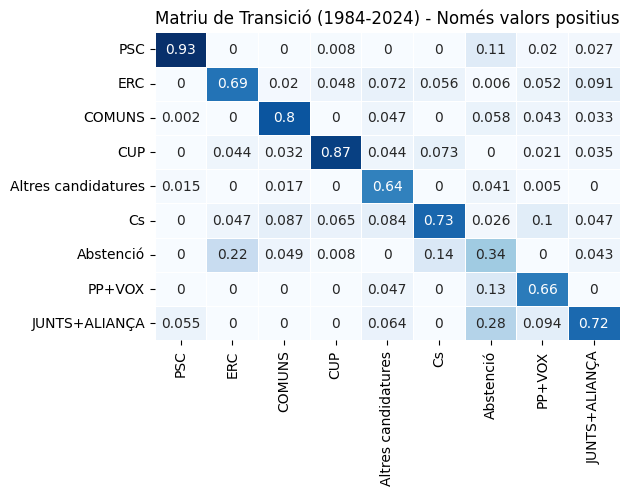

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
sns.heatmap(df_P_final.round(3), annot=True, cmap="Blues", cbar=False, linewidths=0.5)
plt.title("Matriu de Transició (1984-2024) - Només valors positius")
plt.show()

In [6]:
import numpy as np

eigenvalues, eigenvectors = np.linalg.eig(df_P_final)

# Trobar l'índex de l'autovalor més proper a 1
idx = np.argmin(np.abs(eigenvalues - 1))

# Extreure el vector i normalitzar (suma = 1)
pi = np.real(eigenvectors[:, idx])
pi = pi / pi.sum()

partits = list(df_P_final.columns)
for p, v in zip(partits, pi):
    print(f"{p:10s}: {v:.4f}")

###### COMPROVACIÓ DE LA DISTRIBUCIÓ ESTACIONÀRIA ######
print("\nComprovació de la distribució estacionària:")
print(np.allclose(df_P_final @ pi, pi))  # Ha de donar True
print(pi.sum())                    # Ha de donar 1.0

PSC       : 0.2163
ERC       : 0.1116
COMUNS    : 0.0614
CUP       : 0.1851
Altres candidatures: 0.0222
Cs        : 0.1398
Abstenció : 0.0831
PP+VOX    : 0.0352
JUNTS+ALIANÇA: 0.1453

Comprovació de la distribució estacionària:
True
1.0
